In [71]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt

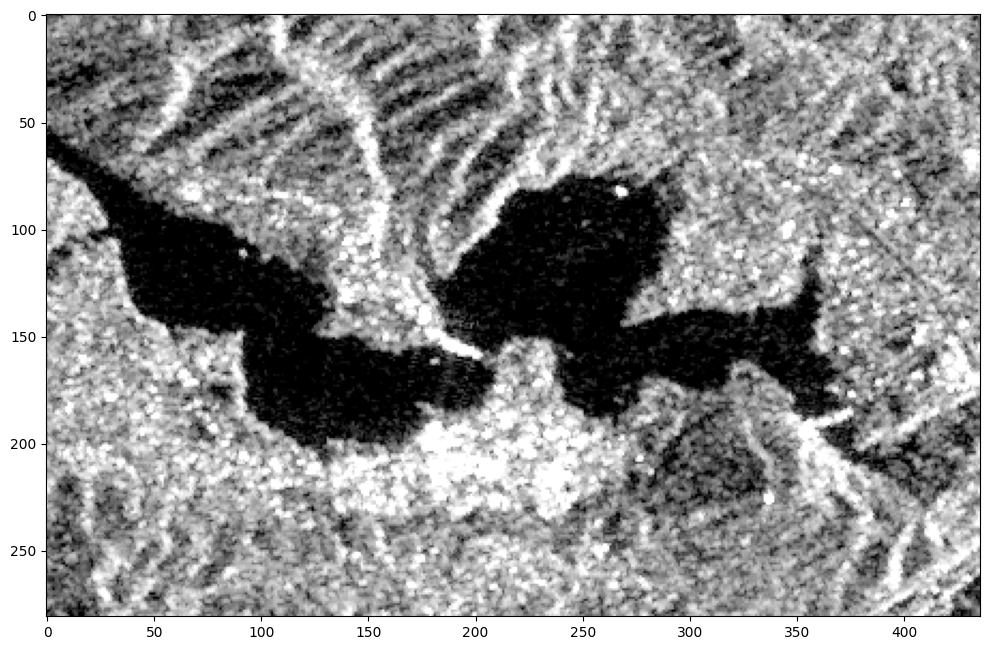

In [85]:
data = '../data/2024-09-09-00_00_2024-09-09-23_59_Sentinel-1_AWS-IW-VVVH_VV_-_decibel_gamma0.tiff'

with rio.open(data) as src:
    img = src.read(1).astype(np.uint16)

p2, p98 = np.nanpercentile(img, [2, 98])

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray', vmin=p2, vmax=p98);
plt.savefig('../output/figure13.png')
plt.tight_layout();

(array([13496.,   474.,   533.,   505.,   474.,   419.,   483.,   508.,
          622.,   404.,   405.,   611.,   335.,   528.,   458.,   462.,
          440.,   582.,   315.,   550.,   539.,   392.,   406.,   557.,
          596.,   591.,   571.,   606.,   603.,   820.,   744.,   691.,
          582.,  1036.,   725.,  1071.,   686.,  1120.,  1093.,  1136.,
          977.,   993.,  1271.,  1507.,  1290.,  1301.,  1245.,  1725.,
         1281.,  1747.,  1259.,  1747.,  1694.,  1721.,  1775.,  1796.,
         1729.,  1933.,  1938.,  1854.,  1896.,  2038.,  1883.,  1805.,
         1869.,  1909.,  1809.,  1963.,  1706.,  1816.,  1754.,  1803.,
         1759.,  1594.,  1579.,  1553.,  1410.,  1516.,  1372.,  1379.,
         1304.,  1205.,  1112.,  1054.,  1010.,   936.,   966.,   806.,
          761.,   727.,   699.,   629.,   654.,   558.,   504.,   537.,
          502.,   460.,   414.,  5313.]),
 array([    0.  ,   655.35,  1310.7 ,  1966.05,  2621.4 ,  3276.75,
         3932.1 ,  4587.45

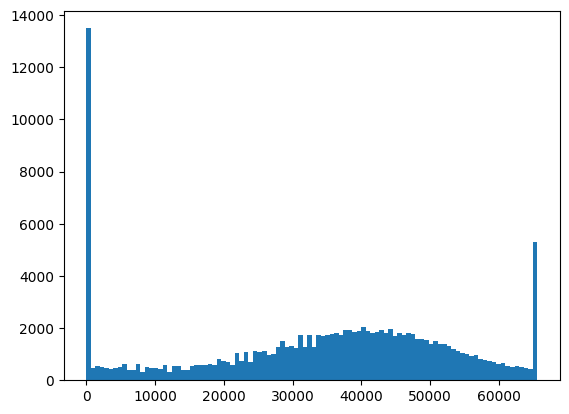

In [101]:
plt.hist(img.flatten(), bins=100)

# 空間分解能でのマルチルック処理

In [87]:
def multilooking(img, n_looks):
    h, w = img.shape
    new_h = h - (h % n_looks)
    new_w = w - (w % n_looks)

    img_clipped = img[:new_h, :new_w]

    reshaped_img = img_clipped.reshape((img_clipped.shape[0] // n_looks), n_looks, img_clipped.shape[1] // n_looks, n_looks)
    multilooked_img = reshaped_img.mean(axis=(1, 3))

    return multilooked_img

In [99]:
multilooked_img_4 = multilooking(img, 4)
multilooked_img_6 = multilooking(img, 6)
multilooked_img_8 = multilooking(img, 8)

print(np.var(img), np.var(multilooked_img_4), np.var(multilooked_img_6), np.var(multilooked_img_8))

361551654.21805805 298968376.05761945 276976364.9365232 257551872.17993215


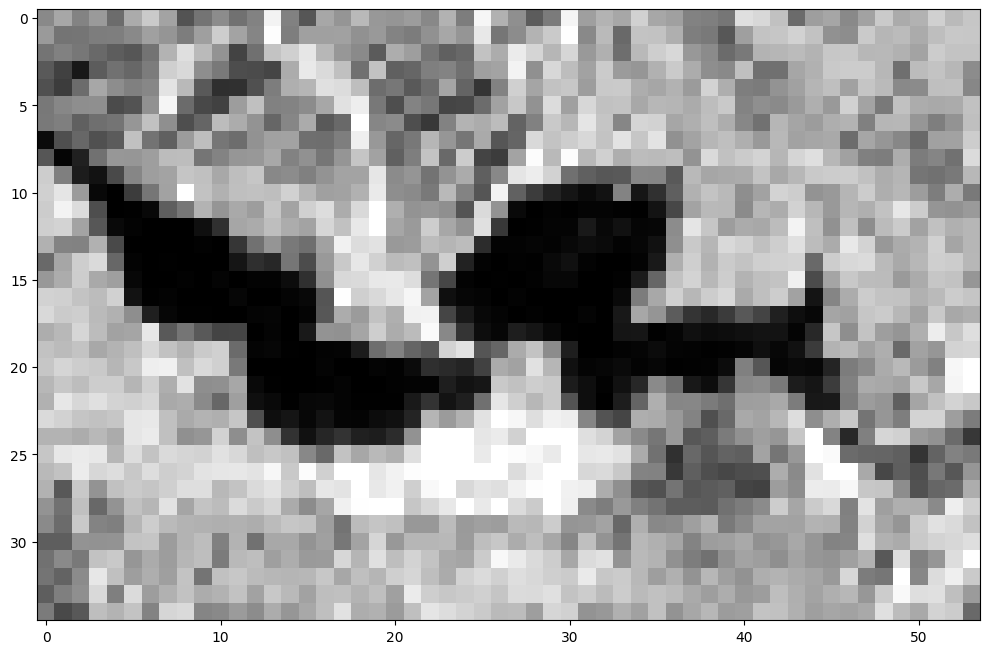

In [98]:
# マルチルック処理の適用
multilooked_img = multilooking(img, 8)

# マルチルック処理後の画像を可視化
p2, p98 = np.nanpercentile(multilooked_img, [2, 98])

plt.figure(figsize=(10, 10))
plt.imshow(multilooked_img, cmap='gray', vmin=p2, vmax=p98)
# plt.savefig('../output/figure14_3.png')
plt.tight_layout();

# 時間分解能でのマルチルック処理

In [114]:
INPUT_DIRECTORY = '../data/'

search_criteria = os.path.join(INPUT_DIRECTORY, '*.tiff')
tiff_files = sorted(glob.glob(search_criteria), reverse=True)

In [134]:
def time_multilooking(image_paths):
    datasets = [rioxarray.open_rasterio(path) for path in image_paths]
    
    combined = xr.concat(datasets, dim='time')
    avg_image = combined.mean(dim='time')

    avg_image = avg_image.astype(datasets[0].dtype)
    
    return avg_image

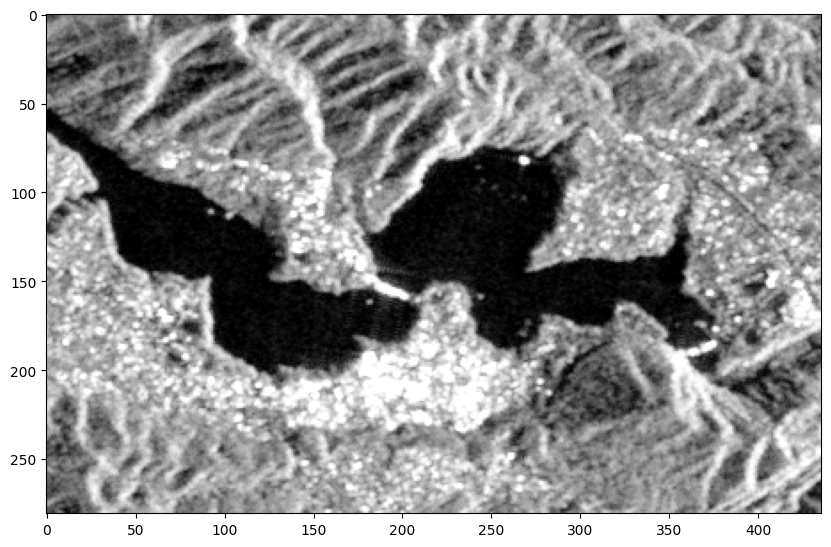

In [139]:
multilooked_img = time_multilooking(tiff_files[:8])

# 2パーセンタイルと98パーセンタイルを計算
p2, p98 = np.nanpercentile(multilooked_img, [2, 98])

# 画像の表示
plt.figure(figsize=(10, 10))
plt.imshow(multilooked_img.isel(band=0), cmap='gray', vmin=p2, vmax=p98);
# plt.savefig('../output/figure15_3.png')